In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:\\Users\\Renu Sharma\\Downloads\\Titanic.csv")
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
# fill missing Age values with median
df['Age'] = df['Age'].fillna(df['Age'].median())

In [6]:
# Fill missing Embarked values with mode

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [7]:
# fill missing cabin values with 'Unknown'

df.drop('Cabin', axis=1, inplace=True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

C:\Users\Renu Sharma\AppData\Local\Temp\ipykernel_15356\3570590431.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df, palette='Set2')


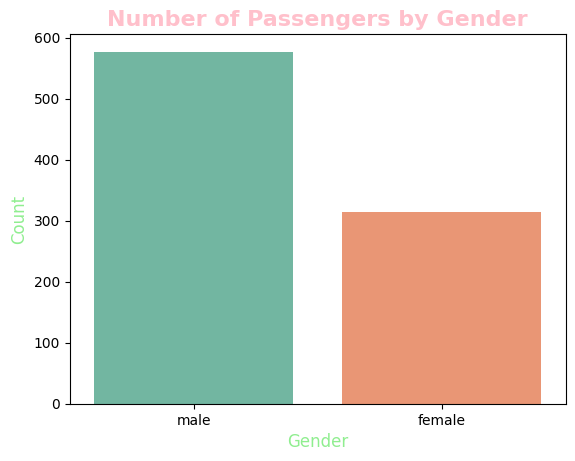

In [11]:
# 1. Create a countplot to show the number of passengers by gender.

sns.countplot(x='Sex', data=df, palette='Set2')
plt.title('Number of Passengers by Gender', fontsize=16, fontweight='bold', color= 'pink')
plt.xlabel('Gender', fontsize=12, color='lightgreen')
plt.ylabel('Count', fontsize=12, color='lightgreen')
plt.show()

C:\Users\Renu Sharma\AppData\Local\Temp\ipykernel_15356\3840938266.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df, palette='Set2')


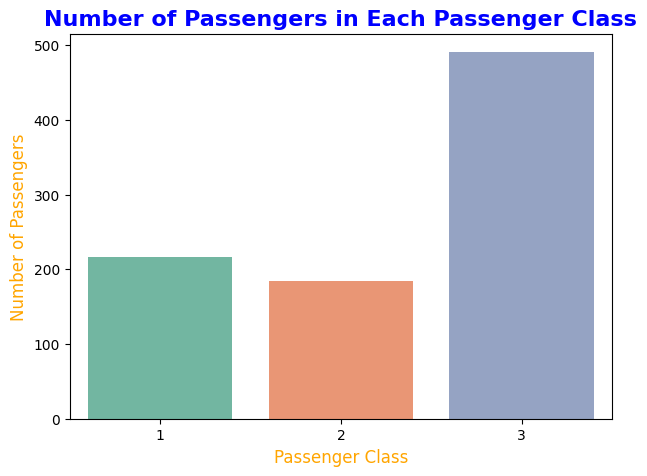

In [12]:
# 2. Create a bar chart to show the number of passengers in each passenger class using different colors.

plt.figure(figsize=(7,5))

sns.countplot(x='Pclass', data=df, palette='Set2')

plt.title("Number of Passengers in Each Passenger Class", fontsize=16, fontweight='bold', color='blue')
plt.xlabel("Passenger Class", fontsize=12, color='orange')
plt.ylabel("Number of Passengers", fontsize=12, color='orange')

plt.show()

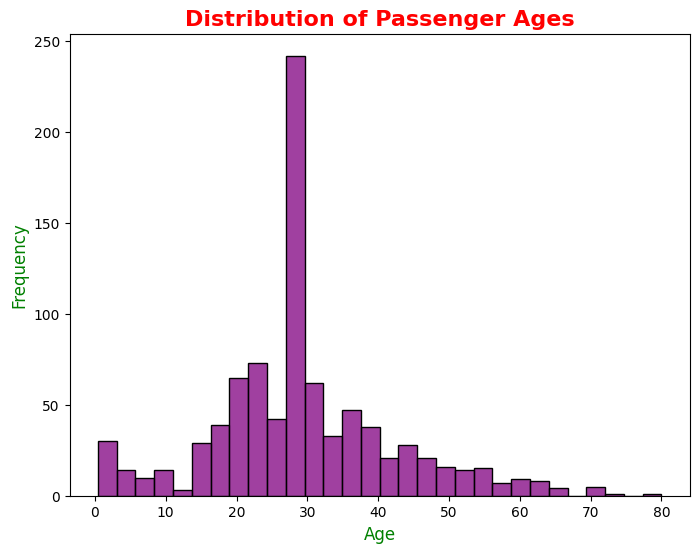

In [13]:
# 3. Create a histogram to show the distribution of passenger age.

plt.figure(figsize=(8,6))

sns.histplot(df['Age'], bins=30,  color='purple')
plt.title("Distribution of Passenger Ages", fontsize=16, fontweight='bold', color='red')
plt.xlabel("Age", fontsize=12, color='green')
plt.ylabel("Frequency", fontsize=12, color='green')
plt.show()

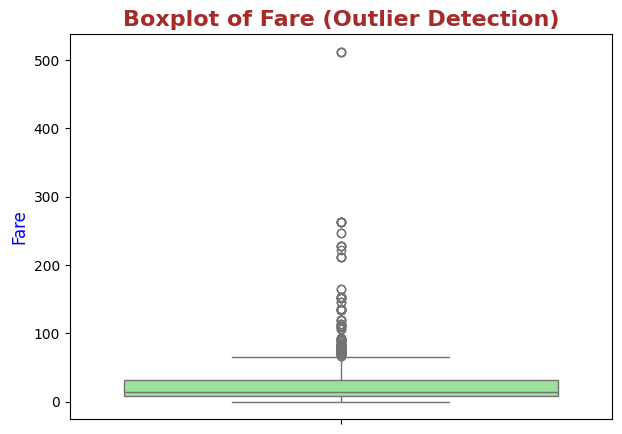

In [14]:
# 4.Create a boxplot to detect outliers in the fare column.

plt.figure(figsize=(7,5))

sns.boxplot(y=df['Fare'], color='lightgreen')

plt.title("Boxplot of Fare (Outlier Detection)", fontsize=16, fontweight='bold', color='brown')
plt.ylabel("Fare", fontsize=12, color='blue')

plt.show()

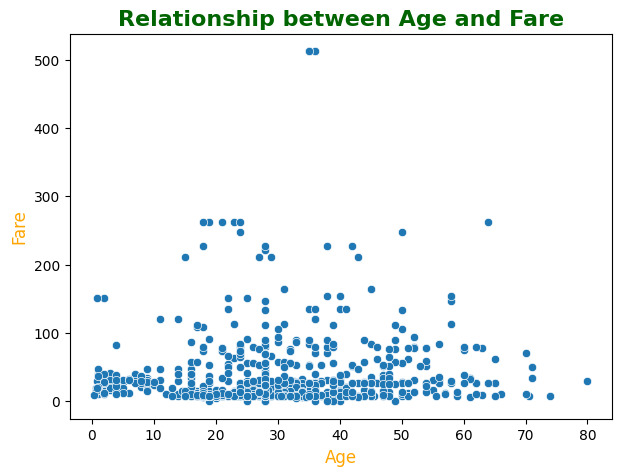

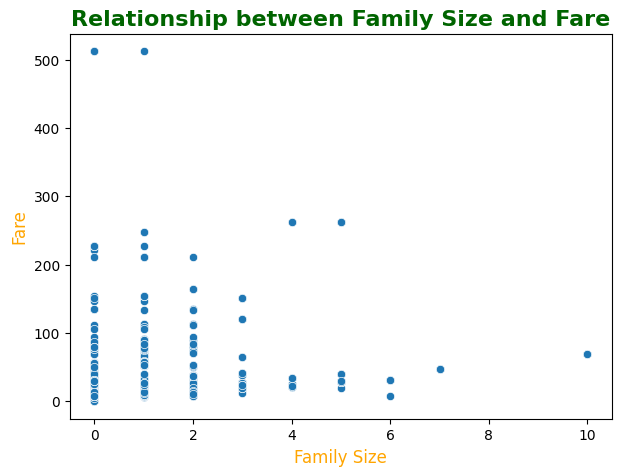

In [15]:
# 5.Create scatterplots

# a) Relationship between Age and Fare
plt.figure(figsize=(7,5))

sns.scatterplot(x='Age', y='Fare', data=df)

plt.title("Relationship between Age and Fare", fontsize=16, fontweight='bold', color='darkgreen')
plt.xlabel("Age", fontsize=12, color='orange')
plt.ylabel("Fare", fontsize=12, color='orange')

plt.show()

# b) Relationship between Family Size and Fare

df['FamilySize'] = df['SibSp'] + df['Parch']

plt.figure(figsize=(7,5))

sns.scatterplot(x='FamilySize', y='Fare', data=df)

plt.title("Relationship between Family Size and Fare", fontsize=16, fontweight='bold', color='darkgreen')
plt.xlabel("Family Size", fontsize=12, color='orange')
plt.ylabel("Fare", fontsize=12, color='orange')

plt.show()

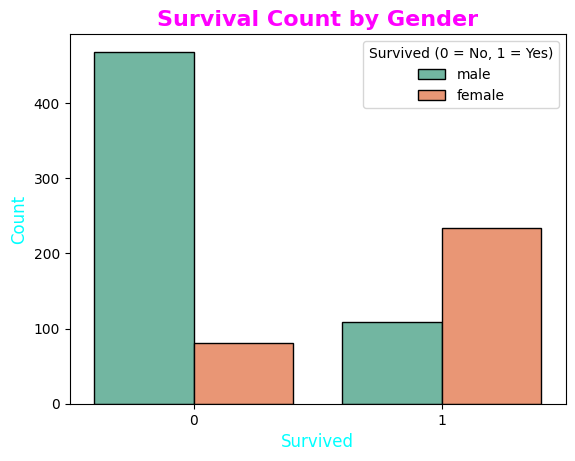

In [16]:
# 6.Create a countplot to show survival count by gender.

sns.countplot(x='Survived', hue='Sex', data=df, palette='Set2', edgecolor='black')
plt.title("Survival Count by Gender", fontsize=16, fontweight='bold', color='magenta')
plt.xlabel("Survived", fontsize=12, color='cyan')   
plt.ylabel("Count", fontsize=12, color='cyan')
plt.legend(title="Survived (0 = No, 1 = Yes)", fontsize=10)
plt.show()

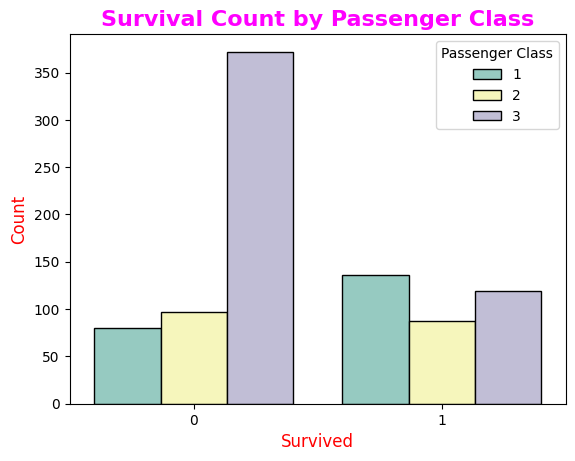

In [17]:
# 7.Create a bar chart to show survival by passenger class.

sns.countplot(x='Survived', hue='Pclass', data=df, palette='Set3', edgecolor='black')
plt.title("Survival Count by Passenger Class", fontsize=16, fontweight='bold', color='magenta')
plt.xlabel("Survived", fontsize=12, color='red')   
plt.ylabel("Count", fontsize=12, color='red')
plt.legend(title="Passenger Class", fontsize=10)    
plt.show()

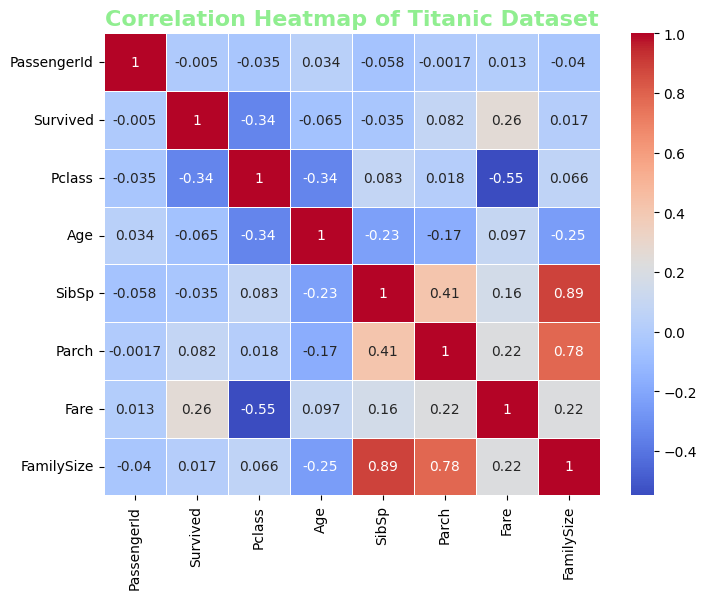

In [18]:
# 8. Create a heatmap to show correlation between numerical variables.

plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5,)

plt.title("Correlation Heatmap of Titanic Dataset", fontsize=16, fontweight='bold', color='lightgreen')

plt.show()

   Pclass       Fare
0       1  84.154687
1       2  20.662183
2       3  13.675550


C:\Users\Renu Sharma\AppData\Local\Temp\ipykernel_15356\1078010776.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Fare', data=avg_fare, palette='Set3')


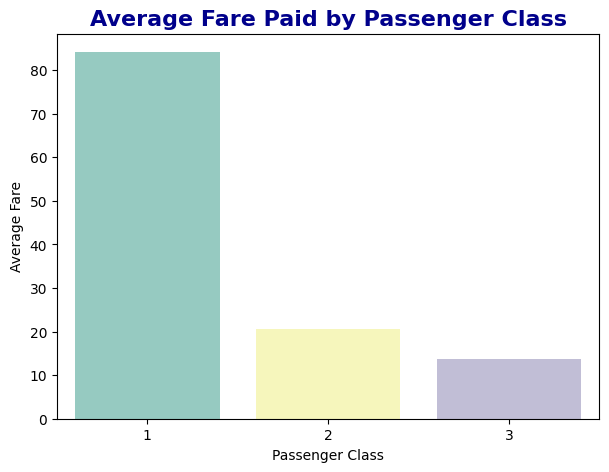

In [19]:
# 9.Identify which passenger class paid the highest fare on average.

avg_fare = df.groupby('Pclass')['Fare'].mean().reset_index()

print(avg_fare)

# bar chart to show average fare by passenger class
plt.figure(figsize=(7,5))

sns.barplot(x='Pclass', y='Fare', data=avg_fare, palette='Set3')

plt.title("Average Fare Paid by Passenger Class", fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")

plt.show()

